# MX6 Maxwell stress / paired phase

## tl;dr

- On all **32,768** public PIConGPU field cells, the paired flip `(E,B) -> (-E,-B)` preserved both Maxwell stress and Poynting flow with numerical relative error `0.0`.
- Flipping only E or only B preserved stress but reversed Poynting flow, also at `0.0` relative error.
- A fixed 3D rotation preserved tensor covariance at `2.95e-16` and stress eigenvalues at `4.04e-16`.
- At the frozen 0.10 null-field rule, **686 cells (2.09%)** occupied the balanced, near-perpendicular radiative sector.
- These results recover Maxwell structure and give the ARA reading a precise crosswalk. They do not independently confirm ARA, and one snapshot cannot show a real temporal half-cycle swap.


## Context & Methods

The proposed ARA reading treats E and B as signed child occurrences whose radiative parent identity survives a joint half-cycle reversal. The Maxwell quantities are

\[
\mathbf S=\mu_0^{-1}\mathbf E\times\mathbf B,
\qquad
T_{ij}=\epsilon_0(E_iE_j-\tfrac12\delta_{ij}E^2)
+\mu_0^{-1}(B_iB_j-\tfrac12\delta_{ij}B^2).
\]

The protocol freezes exact transformation checks, null-field diagnostics, tensor rotation checks and three analytic controls. See `MX6_MAXWELL_STRESS_PHASE_FLIP_PROTOCOL_v1_FROZEN.md`.


In [1]:
from pathlib import Path
import json
import subprocess
import sys
import pandas as pd
import matplotlib.pyplot as plt

HERE = Path(r"F:\SystemFormulaFolder\GIT\ARA-GIT\analysis\electromagnetism")
SOURCE = Path(r"F:\SystemFormulaFolder\work_tmp\ara_mx4\legacy_datasets\picongpu-0.5.0-hdf5-plugin\simData_200.h5")
assert SOURCE.exists(), f"Missing public source: {SOURCE}"
print('Python:', sys.executable)
print('Source:', SOURCE)


Python: F:\SystemFormulaFolder\.venv_ara_verify\Scripts\python.exe
Source: F:\SystemFormulaFolder\work_tmp\ara_mx4\legacy_datasets\picongpu-0.5.0-hdf5-plugin\simData_200.h5


## Data

The source is the CC0 openPMD PIConGPU example snapshot at iteration 200. It contains all six E/B field components on a 32×32×32 Yee grid. The next cell reruns the primary analysis and an independent CSV/JSON arithmetic validator.


In [2]:
commands = [
    [sys.executable, str(HERE / 'mx6_maxwell_stress_phase_flip.py'), '--source', str(SOURCE), '--output-dir', str(HERE)],
    [sys.executable, str(HERE / 'mx6_validate_outputs.py'), '--source', str(SOURCE), '--results-dir', str(HERE)],
]
for command in commands:
    subprocess.run(command, check=True, capture_output=True, text=True)
    print(Path(command[1]).name, 'completed')


mx6_maxwell_stress_phase_flip.py completed


mx6_validate_outputs.py completed


## Results

In [3]:
results = json.loads((HERE / 'MX6_MAXWELL_STRESS_PHASE_FLIP_RESULTS.json').read_text(encoding='utf-8'))
validation = json.loads((HERE / 'MX6_MAXWELL_STRESS_PHASE_FLIP_VALIDATION.json').read_text(encoding='utf-8'))
print('Independent validation:', validation['validation_pass'])
print('Transformation gates:', results['part_a_exact_transformations']['all_relative_l2_errors_le_1e-12'])
print('Rotation gates:', results['part_c_directional_stress']['rotation']['both_errors_le_1e-12'])


Independent validation: True
Transformation gates: True
Rotation gates: True


In [4]:
transform = results['part_a_exact_transformations']
pd.DataFrame([
    {'intervention': 'paired E/B flip', 'stress target': 'same', 'stress error': transform['paired_flip']['stress_relative_l2_to_original'], 'flow target': 'same', 'flow error': transform['paired_flip']['poynting_relative_l2_to_original']},
    {'intervention': 'E-only flip', 'stress target': 'same', 'stress error': transform['electric_only_flip']['stress_relative_l2_to_original'], 'flow target': 'reversed', 'flow error': transform['electric_only_flip']['poynting_relative_l2_to_negative_original']},
    {'intervention': 'B-only flip', 'stress target': 'same', 'stress error': transform['magnetic_only_flip']['stress_relative_l2_to_original'], 'flow target': 'reversed', 'flow error': transform['magnetic_only_flip']['poynting_relative_l2_to_negative_original']},
])


,intervention,stress target,stress error,flow target,flow error
0,paired E/B flip,same,0.0,same,0.0
1,E-only flip,same,0.0,reversed,0.0
2,B-only flip,same,0.0,reversed,0.0


In [5]:
geometry = results['part_b_public_field_geometry']['threshold_sensitivity']
pd.DataFrame([
    {'threshold': value['threshold'], 'null-like cells': value['null_like']['n_cells'], 'fraction of active': value['null_like_fraction_of_active'], 'median |cos(E,B)|': value['null_like']['abs_cos_EB']['percentiles']['p50'], 'median c|B|/|E|': value['null_like']['impedance_ratio_cB_over_E']['percentiles']['p50']}
    for value in geometry.values()
])


,threshold,null-like cells,fraction of active,"median |cos(E,B)|",median c|B|/|E|
0,0.05,191,0.005829,0.023557,0.988220
1,0.10,686,0.020935,0.043781,0.986982
2,0.20,2145,0.065460,0.077867,0.965382


In [6]:
primary = geometry['0.10']
pd.DataFrame([
    {'sector': 'null-like', 'cells': primary['null_like']['n_cells'], 'median |cos(E,B)|': primary['null_like']['abs_cos_EB']['percentiles']['p50'], 'median c|B|/|E|': primary['null_like']['impedance_ratio_cB_over_E']['percentiles']['p50']},
    {'sector': 'non-null active', 'cells': primary['non_null_active']['n_cells'], 'median |cos(E,B)|': primary['non_null_active']['abs_cos_EB']['percentiles']['p50'], 'median c|B|/|E|': primary['non_null_active']['impedance_ratio_cB_over_E']['percentiles']['p50']},
])


,sector,cells,"median |cos(E,B)|",median c|B|/|E|
0,null-like,686,0.043781,0.986982
1,non-null active,32082,0.322316,0.445991


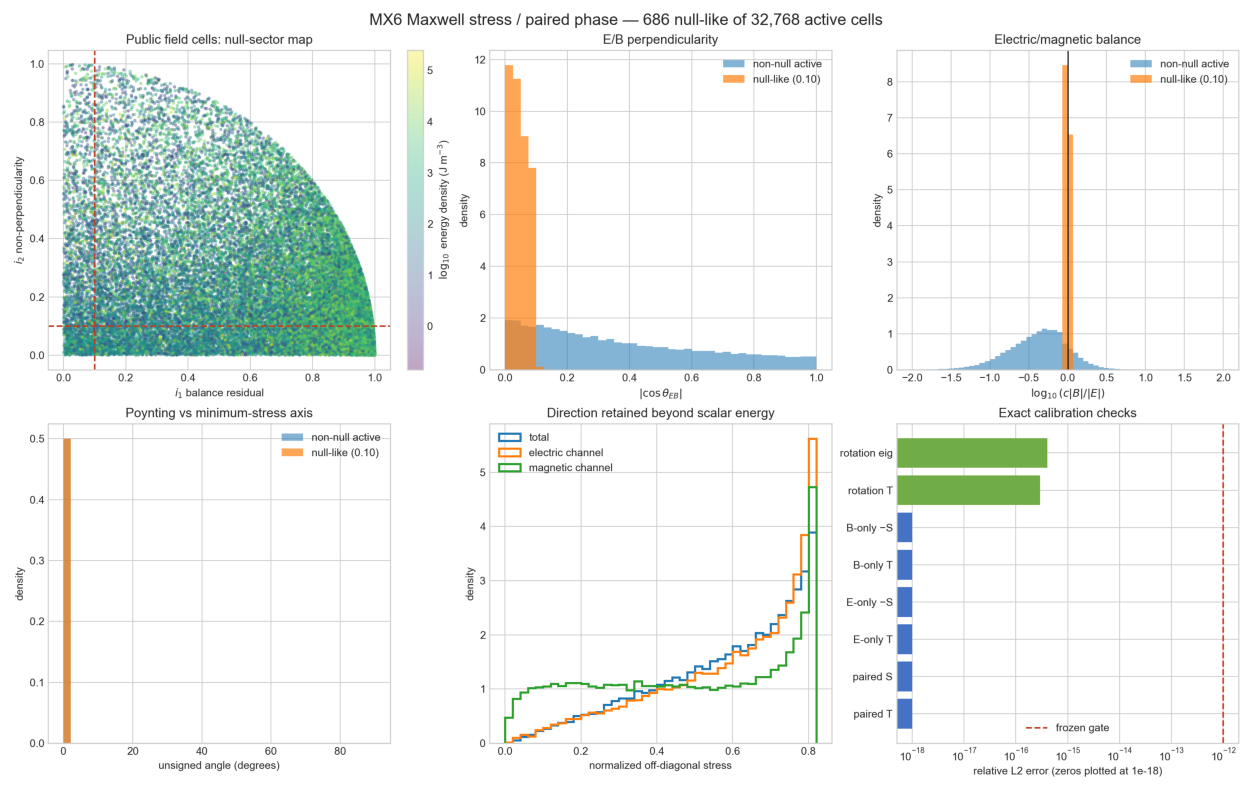

In [7]:
image = plt.imread(HERE / 'MX6_MAXWELL_STRESS_PHASE_FLIP.png')
plt.figure(figsize=(16, 10))
plt.imshow(image)
plt.axis('off')
plt.show()


## Takeaways

1. The joint sign swap preserves the parent Maxwell flow/stress identity exactly; a one-channel swap reverses flow while leaving quadratic stress unchanged.
2. E×B is the minimum-stress eigen-direction for every non-parallel field pair, not only for plane waves. The null/radiative special case additionally requires near-perpendicularity and electric/magnetic balance.
3. The public plasma field contains both sectors: 2.09% is null-like at the primary frozen threshold, so perpendicular E/B must not be generalized to all Maxwell fields.
4. The tensor contains substantial directional information: median normalized off-diagonal content is 0.687 for total stress.
5. The clean next confirmation attempt needs time-resolved E and B snapshots frozen before analysis.
